# Exercise 3 for the class EE-568 Theory and Methods of Reinforcement Learning taught at EPFL in Spring 2026 by Prof. Volkan Cevher

### Names and Sciper numbers

#### Group Member 1:
Name: Louis Grange

Sciper number: 341237

#### Group Member 2:
Name: Raki Ben Mustapha

Sciper number: 344936

#### Group Member 3:
Name: Daniel Ataide

Sciper number: 340497

### LLM Usage

You are encouraged **not to use** LLMs or other AI tools so that you can fully engage with and learn the course material. Uploading the full document or copy-pasting the questions into an AI tool are strictly not allowed. 

If you do use them at any point, please clearly and transparently disclose what tool was used, and how in the next cell. 

If AI use is suspected but not clearly explained, we reserve the right to ask follow-up questions to clarify your understanding of the work. 

In [10]:
### Do the imports -- no need to change this
import numpy as np
from typing import List
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import sys
sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from utils import *
from plot import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


***Before starting, we recall the use of the gridworld environment.***

The gridworld environment is instantiated via the class `GridWorldEnvironment`. 

***It takes 4 input values:***
- `reward_mode` : Integer between 0 and 3 for different reward profiles,
- `size`: Gridworld size,
- `prop`: Probability assigned to the event that the agent does not follow the chosen action but another one selected uniformely at random,
- `gamma`: Discount factor of the environment.

***Interface of a Gridworld instance:***
- `print(gridworld.n_states)` # return the number of states
- `print(gridworld.n_actions)` # return the number of actions
- `print(gridworld.r)` # return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` # Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.

<img src="../dynamic_programming/src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

# Ex 1: Prove of the Policy Gradient Theorem via the Performance Difference Lemma (20 points)

Denote $J(\pi) = \langle \mu, V^\pi \rangle$ and recall that the performance difference lemma states
$$
J(\pi) - J(\pi') = \frac{1}{(1-\gamma)}\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]
$$
where $\lambda^{\pi'} \in \Delta_{\mathcal{S}\times\mathcal{A}}$ denotes the occupancy measure of the policy $\pi'$.

Now let us consider direct parametization, and compute a partial derivative for the entry of $\pi$ at index $(\bar{s},\bar{a})$:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})}.
$$

**Questions**

To help you compute this partial derivative, consider the policies $\pi'$ parameterized by some (sufficiently small) $\delta \in \mathbb{R}$ via
$$
    \pi'(a|s) = \begin{cases}
        \pi(\bar{a}|\bar{s}) + \delta \quad (\text{if } (s,a)=(\bar{s},\bar{a}))\\
        \pi(a|s) \quad (\text{else})
    \end{cases}
$$

(1) Argue that
$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}.
$$

**Answer**

The partial derivative with respect to a single policy entry is by definition:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \lim_{\delta \to 0} \frac{J(\pi) - J(\pi')}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}
$$

And if we look at the perturbed policy $\pi '$, we can write $\pi'(\bar{a}|\bar{s}) = \pi(\bar{a}|\bar{s}) + \delta$ as:

$$
\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s}) = -\delta
$$

If we put the these 2 equations together we see the limit above is equal to:

$$
\lim_{\delta \to 0} \frac{J(\pi) - J(\pi')}{-\delta}
$$

And this is the standard definition of the partial derivative. If we now aply the PDL (lecture 4, slide 43) to the numerator $J(\pi) - J(\pi')$:

$$
J(\pi) - J(\pi') = \frac{1}{1-\gamma} \mathbb{E}_{s \sim \lambda^{\pi'}} \big[\langle \pi(\cdot|s) - \pi'(\cdot|s),\; Q^\pi(s,\cdot) \rangle \big]
$$

Substituting this into the derivative expression gives:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \lim_{\delta \to 0} \frac{1}{1-\gamma} \cdot \frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle \pi(\cdot|s) - \pi'(\cdot|s),\; Q^\pi(s,\cdot) \rangle]}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}
$$

(2) Argue that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \lambda^{\pi'}(\bar{s}) Q^\pi(\bar{s}, \bar{a}).$$

Hint: Write the expectation in the previous question as a sum and use the fact that $\frac{\pi(a|s) - \pi'(a|s)}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})} = \mathbf{1}_{\{ (\bar{s},\bar{a}) = (s,a) \}}$.

**Answer**

We start from part 1 and write the expectation as a sum over all state action pairs:

$$
\frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle \pi(\cdot|s) - \pi'(\cdot|s),\; Q^\pi(s,\cdot) \rangle]}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})} = \sum_{s} \lambda^{\pi'}(s) \sum_{a} \frac{\pi(a|s) - \pi'(a|s)}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})} \, Q^\pi(s,a)
$$

Now, using the hint provided, we see that the double sum collapses into a single term:

$$
\sum_{s,a} \lambda^{\pi'}(s)\, \mathbf{1}_{\{(s,a) = (\bar{s},\bar{a})\}}\, Q^\pi(s,a) = \lambda^{\pi'}(\bar{s})\, Q^\pi(\bar{s}, \bar{a})
$$

And if we substitute back:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{1-\gamma} \lim_{\delta \to 0} \lambda^{\pi'}(\bar{s})\, Q^\pi(\bar{s}, \bar{a})
$$


(3) Conclude that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lambda^{\pi}(\bar{s}) Q^\pi(\bar{s}, \bar{a})$$
for the direct parameterization. 

**Answer**

We start from the result of part 2:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{1-\gamma} \lim_{\delta \to 0} \lambda^{\pi'}(\bar{s})\, Q^\pi(\bar{s}, \bar{a})
$$

We notice that $Q^\pi(\bar{s}, \bar{a})$ does not depend on $\delta$, so we only need to evaluate the limit of $\lambda^{\pi'}(\bar{s})$.

As $\delta \to 0$, $\pi'$ converges to $\pi$ (since $\pi'(a|s) \to \pi(a|s), \forall (s,a)$).

And as the occupancy measure $\lambda^{\pi'}$ depends on the policy $\pi'$, we get:

$$
\lim_{\delta \to 0} \lambda^{\pi'}(\bar{s}) = \lambda^{\pi}(\bar{s})
$$

And if we substitute, we obtain:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{1-\gamma}\, \lambda^{\pi}(\bar{s})\, Q^\pi(\bar{s}, \bar{a})
$$


(4) Prove that for a general parametrization, it holds that
$$
\nabla_\theta J(\pi_\theta) = \frac{1}{(1-\gamma)} \sum_{\bar{s},\bar{a}} \lambda^{\pi}(\bar{s}, \bar{a}) Q^\pi(\bar{s}, \bar{a}) \nabla_{\theta} ( \log \pi_\theta(\bar{a}|\bar{s}))
$$

Hint: Use the chain rule to write $$ \nabla_\theta J(\pi_\theta)  = \sum_{\bar{s},\bar{a}} \frac{\partial J(\pi)}{\partial \pi_\theta(\bar{a}|\bar{s})} \nabla_{\theta} \pi_\theta(\bar{a}|\bar{s}), $$
and then use the fact that $\lambda^{\pi}(\bar{s},\bar{a}) = \lambda^{\pi}(\bar{s}) \pi(\bar{a}|\bar{s})$.

**Answer**

Let's start by applying the chain rule for a general parameterization $\pi_\theta$:

$$
\nabla_\theta J(\pi_\theta) = \sum_{\bar{s},\bar{a}} \frac{\partial J(\pi)}{\partial \pi_\theta(\bar{a}|\bar{s})} \, \nabla_\theta \pi_\theta(\bar{a}|\bar{s})
$$

Then we substitute the result from part 3:

$$
\nabla_\theta J(\pi_\theta) = \sum_{\bar{s},\bar{a}} \frac{1}{1-\gamma}\, \lambda^{\pi}(\bar{s})\, Q^\pi(\bar{s},\bar{a}) \, \nabla_\theta \pi_\theta(\bar{a}|\bar{s})
$$

And in here if we apply the log-derivative trick in slide 14, lecture 4
($\nabla_\theta \pi_\theta(\bar{a}|\bar{s}) = \pi_\theta(\bar{a}|\bar{s}) \, \nabla_\theta \log \pi_\theta(\bar{a}|\bar{s})$), we get:

$$
\nabla_\theta J(\pi_\theta) = \frac{1}{1-\gamma} \sum_{\bar{s},\bar{a}} \lambda^{\pi}(\bar{s})\, \pi_\theta(\bar{a}|\bar{s})\, Q^\pi(\bar{s},\bar{a}) \, \nabla_\theta \log \pi_\theta(\bar{a}|\bar{s})
$$

We're almost done, just need to use the fact that $\lambda^{\pi}(\bar{s},\bar{a}) = \lambda^{\pi}(\bar{s})\, \pi(\bar{a}|\bar{s})$ and we get a final resutl of:

$$
\nabla_\theta J(\pi_\theta) = \frac{1}{1-\gamma} \sum_{\bar{s},\bar{a}} \lambda^{\pi}(\bar{s},\bar{a})\, Q^\pi(\bar{s},\bar{a}) \, \nabla_\theta \log \pi_\theta(\bar{a}|\bar{s})
$$

This is the Policy Gradient Theorem in its occupancy measure form (slide 26, eq.4), with the expectation written as a sum over all state action pairs and the hint provided in part 2.

# Ex 2: Natural Policy Gradient with softmax parameterization (20 points)

Recall that the iterates $\{\pi^t\}^{\infty}_{t=1}$ produced by NPG read as follows:
$$
\pi^{t+1}(a|s) = \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}}.
$$

Implement NPG for an arbitrary step size $\eta$. Please note that $e^{\eta Q^{\pi^t}(s,a)}$ can be zero, account for that in your implementation.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

In [11]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy 
    Args:
        pi: a policy stochastic passed with shape n_states times n_actions
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v)
        for s in range(env.n_states):
            v[s] = q[s].dot(pi[s])
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

def npg_update(q, eta, old_policy):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        new_policy: the updates policy
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        policy[s] = (old_policy[s] * np.exp(eta * q[s]))
        total = np.sum(policy[s])
        if total == 0:
             policy[s] = np.ones(q.shape[1])/q.shape[1]
        else:
            policy[s] = (old_policy[s] * np.exp(eta * q[s])) / (np.sum(old_policy[s] * np.exp(eta * q[s])))
    return policy

def get_greedy_policy(q):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        policy: greedy policy (list)
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        policy[s,np.argmax(q[s,:])] = 1
    return policy

In [12]:
def NPG(env, eta): # apply NPG iterations for 30 steps
    vs = []
    policies = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.ones_like(q)/env.n_actions
    for k in range(30):
        v_old = np.copy(v)
        v, q = evaluate_policy(pi, env)
        if eta < np.inf:
            pi = npg_update(q, eta, pi)
        else:
            pi = get_greedy_policy(q)
        vs.append(v)
        policies.append(pi)
    return vs, policies

Now, we run NPG for different stepsizes in the usual gridworld environment

In [13]:
reward_mode = 2
size = 10 
prop = 0
gamma=0.99
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
mu = np.ones(gridworld.n_states)/gridworld.n_states
etas = [1e-3, 1e-2, 1e-1, 1, 100, 1e7, np.inf]
v_different_etas = []
pi_different_etas = []
for eta in etas:
    values_pi, policies = NPG(gridworld, eta=eta)
    v_different_etas.append(values_pi)
    pi_different_etas.append(policies)

In [14]:
solver = MDPsolver(gridworld)
solver.value_iteration()

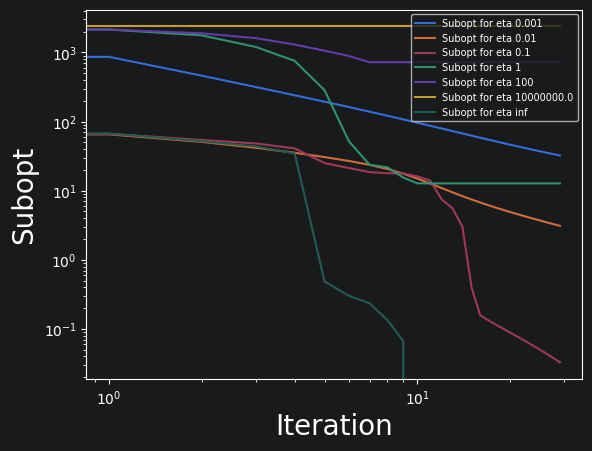

In [15]:
# TODO: if this plot appears with a too large legend, rerun this line once more
plot_log_lines([np.array([mu.dot(solver.v - v) for v in v_different_etas[i]]) for i, _ in enumerate(etas)], [f"Subopt for eta {eta}" for eta in etas], ["Iteration", "Subopt"], "figs", "NPG.pdf", show = True)

**Question**

Show that NPG with $\eta = \infty$ coincides with Policy Iteration (PI).

More formally: Assuming that $a^\star_s := \mathrm{argmax}_a Q^{\pi^t}(s,a)$ is unique for all $s$, prove that $$ \lim_{\eta \rightarrow \infty} \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}} = \begin{cases} 1 \quad \text{if} \quad a = a^\star_s \\ 0 \quad \text{otherwise} \end{cases},$$
and explain how this relates to PI.

**Answer**

If we define $Q^\star := Q^{\pi^t}(s, a^\star_s) = \max_{a'} Q^{\pi^t}(s, a')$ and then try to factor out $e^{\eta Q^\star}$ from both numerator and denominator:

$$
\frac{\pi^t(a|s) \, e^{\eta Q^{\pi^t}(s,a)}}{\sum_{a'} \pi^t(a'|s) \, e^{\eta Q^{\pi^t}(s,a')}} = \frac{\pi^t(a|s) \, e^{\eta (Q^{\pi^t}(s,a) - Q^\star)}}{\sum_{a'} \pi^t(a'|s) \, e^{\eta (Q^{\pi^t}(s,a') - Q^\star)}}
$$

Here, we have $Q^{\pi^t}(s,a') - Q^\star \leq 0$ for all $a'$, with equality only when $a' = a^\star_s$. This means we can separate things into 2 distinct cases.

**Case 1: $a \neq a^\star_s$.** The numerator contains $e^{\eta(Q^{\pi^t}(s,a) - Q^\star)}$ where $Q^{\pi^t}(s,a) - Q^\star < 0$. As $\eta \to \infty$, this goes to $0$. The denominator is bounded below by the $a^\star_s$ term: $\pi^t(a^\star_s|s) \cdot e^{0} = \pi^t(a^\star_s|s) > 0$ (since $\pi^t$ is initialized as uniform and remains strictly positive under the multiplicative update). So the ratio goes $\to 0$.

**Case 2: $a = a^\star_s$.** We get:

$$
\frac{\pi^t(a^\star_s|s)}{\pi^t(a^\star_s|s) + \sum_{a' \neq a^\star_s} \pi^t(a'|s) \, e^{\eta(Q^{\pi^t}(s,a') - Q^\star)}}
$$

Every term in the sum over $a' \neq a^\star_s$ has $Q^{\pi^t}(s,a') - Q^\star < 0$, so $e^{\eta(Q^{\pi^t}(s,a') - Q^\star)} \to 0$ as $\eta \to \infty$. Hence the denominator converges to $\pi^t(a^\star_s|s)$, and the ratio $\to 1$.

Trying to connect this to Policy Iteration, we see in supplementary slide 9 of lecture 5, recalling PI step:

$$
\pi^{t+1}(a|s) = \begin{cases} 1 & \text{if } a = \mathrm{argmax}_{a'} Q^{\pi^t}(s,a') \\ 0 & \text{otherwise} \end{cases}
$$

NPG with $\eta \to \infty$ coincides with PI: each iteration does exact policy evaluation followed by greedy policy improvement.

**Question**

Is this observation in line with the empirical results in the plot above? I.e., is the plot for $\eta = \infty$ as you would expect it for PI?

**Answer**

The plot is consistent with what we expect from PI. The $\eta = \infty$ curve achieves the fastest convergence among all, only needing 8-9 iterations for a near-zero suboptimality. This matches the known behaviour of PI.

On the other hand, smaller step sizes converge much slower, since the policy changes only incrementally. It's interesting to note that for larger values ($\eta = 100, 10^7$), we have an extremely poor performance and this is likely due to some numerical issues in get_greedy_policy and by directly using $\infty$ we're able to bypass this problem.

# Ex 2.2 Slow Changing Property of NPG

In this exercise you will investigate by how much consecutive iterates $\pi^t$ and $\pi^{t+1}$ produced by NPG differ and how this distance is controlled by the step size $\eta$.

Plot $$\max_{s \in \mathcal{S}} || \pi^{t+1}(a|s) - \pi^t(a|s) ||_1$$ for different values of $\eta$.

In [16]:
def compute_policy_variation(policies):
    variation = []
    for pi, pip in zip(policies[1:], policies[:-1]):
        variation.append(np.max([np.sum(np.abs(pi[s] - pip[s])) for s in range(pi.shape[0])]))
    return variation

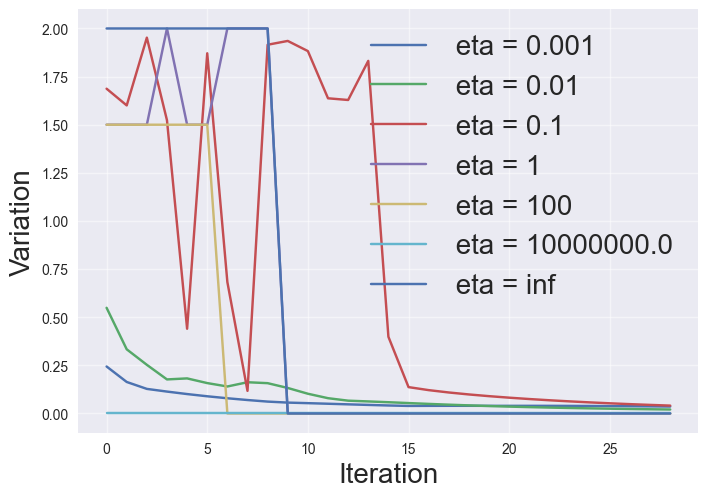

In [17]:
plot_lines(np.array([ compute_policy_variation(np.array(pi_different_etas)[i])
                           for i, _ in enumerate(etas)]),
               [f" eta = {eta}" for eta in etas], 
               ["Iteration", "Variation"], "figs", "NPG.pdf", show = True)

**Question**

Empirically, is the largest change (among all iterations) between consecutive iterations is larger for smaller or large values of $\eta$?

It is smaller for smaller values of $\eta$ (for $\eta = \infty$ we have a high variation)

## Some Theory to Motivate the Observation Above

**Question**

Our goal is to prove that $$ || \pi^{t+1}(\cdot|s) - \pi^t(\cdot|s) ||_1 \leq \frac{\eta}{1 - \gamma} \quad \forall s \in \mathcal{S}, \forall t \in [T].$$

We guide you towards this result by breaking the proof into small steps.

1) Prove that $$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] - \log \bigg(\sum_{a'\in\mathcal{A}} \pi^t(a'|s) \exp (\eta Q^{\pi^t}(s,a'))\bigg) $$

Hint: First apply Pinkser's inequality https://en.wikipedia.org/wiki/Pinsker%27s_inequality to prove that $$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq KL(\pi^{t+1}(s)||\pi^t(s)), $$ then plug in the formula for $\pi^{t+1}$ into the KL term.

**Answer**

Based on Pinsker's inequality ,for any two distributions $p, q$ on $\mathcal{A}$,
                                                                                                                                                                   
  $$\frac{1}{2} \| p - q \|_1^2 \leq KL(p \,\|\, q)$$
                                                                                                                                                                   
  Applying this with $p = \pi^{t+1}(\cdot|s)$ and $q = \pi^t(\cdot|s)$:

  $$\frac{1}{2} \| \pi^{t+1}(s) - \pi^t(s) \|_1^2 \leq KL\left(\pi^{t+1}(s) \,\big\|\, \pi^t(s)\right)$$

  We then plug in the NPG update into the KL 

  $$Z(s) = \sum_{a' \in \mathcal{A}} \pi^t(a'|s) \exp\big(\eta Q^{\pi^t}(s,a')\big).$$

  Then $\pi^{t+1}(a|s) = \dfrac{\pi^t(a|s) \exp(\eta Q^{\pi^t}(s,a))}{Z(s)}$, so the log-ratio simplifies:

  $$\log \frac{\pi^{t+1}(a|s)}{\pi^t(a|s)} = \log \frac{\pi^t(a|s) \exp(\eta Q^{\pi^t}(s,a))}{\pi^t(a|s) \, Z(s)} = \eta Q^{\pi^t}(s,a) - \log Z(s).$$

  Therefore,

  $$
  \begin{aligned}
  KL\left(\pi^{t+1}(s) \,\big\|\, \pi^t(s)\right)
  &= \sum_{a} \pi^{t+1}(a|s) \log \frac{\pi^{t+1}(a|s)}{\pi^t(a|s)} \\
  &= \sum_{a} \pi^{t+1}(a|s) \Big[\eta Q^{\pi^t}(s,a) - \log Z(s)\Big] \\
  &= \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}\big[\eta Q^{\pi^t}(s,a)\big] - \log Z(s),
  \end{aligned}
  $$

  Based on the three equations, we finally find :

  $$\frac{1}{2} \| \pi^{t+1}(s) - \pi^t(s) \|_1^2 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}\big[\eta Q^{\pi^t}(s,a)\big] - \log\left(\sum_{a' \in \mathcal{A}}
  \pi^t(a'|s) \exp\big(\eta Q^{\pi^t}(s,a')\big)\right)$$

2) Prove that 
$$
\sum_{a\in \mathcal{A}} \pi^{t+1}(a|s) \exp(- \eta Q^{\pi^t}(s,a)) = \frac{1}{\sum_{a'\in \mathcal{A}} \pi^t(a|s) \exp(\eta Q^{\pi^t}(s,a) )}.
$$

**Answer**

  We have from before that :
  $$\pi^{t+1}(a|s) = \frac{\pi^t(a|s) \exp(\eta Q^{\pi^t}(s,a))}{Z(s)}$$
   Multiplying both sides by $\exp(-\eta Q^{\pi^t}(s,a))$:                                                               

  $$\pi^{t+1}(a|s) \exp\big(-\eta Q^{\pi^t}(s,a)\big) = \frac{\pi^t(a|s) \exp(\eta Q^{\pi^t}(s,a)) \exp(-\eta Q^{\pi^t}(s,a))}{Z(s)} = \frac{\pi^t(a|s)}{Z(s)}$$

  Now sum over $a \in \mathcal{A}$. Since $Z(s)$ does not depend on $a$ and $\sum_{a} \pi^t(a|s) = 1$:

  $$\sum_{a \in \mathcal{A}} \pi^{t+1}(a|s) \exp\big(-\eta Q^{\pi^t}(s,a)\big) = \frac{1}{Z(s)} \sum_{a \in \mathcal{A}} \pi^t(a|s) = \frac{1}{Z(s)}$$

  Substituting the definition of $Z(s)$ gives :

  $$\sum_{a \in \mathcal{A}} \pi^{t+1}(a|s) \exp\big(-\eta Q^{\pi^t}(s,a)\big) = \frac{1}{\sum_{a' \in \mathcal{A}} \pi^t(a'|s) \exp\big(\eta
  Q^{\pi^t}(s,a')\big)}$$

3) Using the results in 1) and 2) prove that 

$$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] + \log \bigg(\sum_{a'\in\mathcal{A}} \pi^{t+1}(a'|s) \exp (-\eta Q^{\pi^t}(s,a'))\bigg). $$

**Answer**

 From part 1) we have                                                                                                                                              $$\frac{1}{2} \| \pi^{t+1}(s) - \pi^t(s) \|_1^2 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}\big[\eta Q^{\pi^t}(s,a)\big] - \log\left(\sum_{a' \in \mathcal{A}}
  \pi^t(a'|s) \exp\big(\eta Q^{\pi^t}(s,a')\big)\right)$$                                                                                 
                  
  From part 2) we have

  $$\sum_{a \in \mathcal{A}} \pi^{t+1}(a|s) \exp\big(-\eta Q^{\pi^t}(s,a)\big) = \frac{1}{\sum_{a' \in \mathcal{A}} \pi^t(a'|s) \exp\big(\eta
  Q^{\pi^t}(s,a')\big)}$$

  Taking the logarithm of both sides:

  $$\log\!\left(\sum_{a' \in \mathcal{A}} \pi^{t+1}(a'|s) \exp\big(-\eta Q^{\pi^t}(s,a')\big)\right) = - \log\left(\sum_{a' \in \mathcal{A}}
  \pi^t(a'|s) \exp\big(\eta Q^{\pi^t}(s,a')\big)\right)$$

  Plugging the last result into the first equation

  $$\frac{1}{2} \| \pi^{t+1}(s) - \pi^t(s) \|_1^2 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}\big[\eta Q^{\pi^t}(s,a)\big] + \log\!\left(\sum_{a' \in \mathcal{A}}
  \pi^{t+1}(a'|s) \exp\big(-\eta Q^{\pi^t}(s,a')\big)\right)$$

4) Using Hoeffding's Lemma https://en.wikipedia.org/wiki/Hoeffding%27s_lemma (on the sum in the log term!) and the fact that $$-\frac{1}{1-\gamma} \leq Q^{\pi^t}(s,a) \leq \frac{1}{1-\gamma},$$ conclude that 
$$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \frac{\eta^2}{2 (1 - \gamma)^2}.$$

**Answer**

From part 3) we have                                                                                                                                             
                                                                                                                                                                   
  $$\frac{1}{2} \| \pi^{t+1}(s) - \pi^t(s) \|_1^2 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}\big[\eta Q^{\pi^t}(s,a)\big] + \log\!\left(\mathbb{E}_{a \sim        
  \pi^{t+1}(\cdot|s)}\big[\exp(-\eta Q^{\pi^t}(s,a))\big]\right)$$                                                                                 
                  

 Hoeffding's Lemma states: if $X$ is a random variable with $X \in [b_-, b_+]$ almost surely, then for all $\lambda
  \in \mathbb{R}$,

  $$\log \mathbb{E}\big[\exp(\lambda(X - \mathbb{E}[X]))\big] \leq \frac{\lambda^2 (b_+ - b_-)^2}{8}, \quad\text{equivalently,}\quad \log \mathbb{E}[\exp(\lambda
  X)] \leq \lambda \mathbb{E}[X] + \frac{\lambda^2 (b_+ - b_-)^2}{8}$$

  Take $X = Q^{\pi^t}(s,a)$ with $a \sim \pi^{t+1}(\cdot|s)$, and $\lambda = -\eta$. By assumption $X \in \big[-\tfrac{1}{1-\gamma},\, \tfrac{1}{1-\gamma}\big]$,
  so $b_+ - b_- = \tfrac{2}{1-\gamma}$. Hoeffding's Lemma gives

  $$
  \begin{aligned}
  \log\!\left(\mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}\big[\exp(-\eta Q^{\pi^t}(s,a))\big]\right)
  &\leq -\eta\, \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}\big[Q^{\pi^t}(s,a)\big] + \frac{\eta^2}{8}\!\left(\frac{2}{1-\gamma}\right)^2 \\
  &= -\mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}\big[\eta Q^{\pi^t}(s,a)\big] + \frac{\eta^2}{2(1-\gamma)^2}
  \end{aligned}
  $$

Substituting this bound into the first equation, we get:

  $$\frac{1}{2} \| \pi^{t+1}(s) - \pi^t(s) \|_1^2 \leq \mathbb{E}_{a \sim \pi^{t+1}}\big[\eta Q^{\pi^t}(s,a)\big] - \mathbb{E}_{a \sim \pi^{t+1}}\big[\eta
  Q^{\pi^t}(s,a)\big] + \frac{\eta^2}{2(1-\gamma)^2} = \frac{\eta^2}{2(1-\gamma)^2} $$

# Ex 3: OPPO: The importance of Exploration in Policy Gradient (20 points)

In this exercise, we will investigate how crucial it is to perform exploration. That is, adding bonuses to avoid suffering the mismatch coefficients in the convergence bounds.

Let us recall that the standard sample based version of NPG suffers the mismatch coeffcients in the bounds (see Slide 22 in Lecture 5). Those are avoided by OPPO ( See slide 30 in Lecture 5 ).

**To see clearly the advatange of OPPO we will consider an MDP with unbounded mismatch coefficients**

**Question: example of unbounded mismatch coefficients**

Consider a 10 x 10 gridworld, the initial state is always the bottom right corner, i.e. the initial distribution $\mu$ equals $1$ at this starting state and it is zero everywhere else. Can you compute a finite bound for 
$$\max_\pi \max_{s \in \mathcal{S}} \bigg |\frac{\lambda^\pi(s)}{\mu(s)} \bigg|,$$
i.e. the mismatch coefficient? If not, argue for which reason.

**Answer**



_We cannot compute a finite bound for the mismatch coefficient, since $\mu$ lacks support over the state space ($\mu(s) = 0$ everywhere except at starting state), and we have $\lambda^\pi(s) > 0$ (some policies manage to go on other cases), therefore the ratio tends to infinity._

In the following, we experiment with OPPO with and without bonuses in this environment.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

In [8]:
reward_mode = 0
size = 10
gamma=0.999
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
r_max = np.max(gridworld.r)
r_min = np.min(gridworld.r)
gridworld.r = (gridworld.r - r_min) / (r_max - r_min)

In [15]:
from copy import deepcopy
np.random.seed(0)
def oppo(K: int = 10000, H: int = 20, beta: float = 0.0001, eta=5) -> List[float]:
    """
    Function implementing OPPO with UCB bonuses algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param beta: Algorithm hyperparameter, constant which scales the bonuses, positive float

    :return: reward after each step, list of K * H floats
    """

    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    policy = H * np.ones((H, gridworld.n_states, gridworld.n_actions))/gridworld.n_actions
    V[H, :] = 0
    estimated_transitions = np.ones((H, gridworld.n_states, 
                                     gridworld.n_actions, 
                                     gridworld.n_states))/gridworld.n_states
    N = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    bonus = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    N_next = np.zeros((H, gridworld.n_states, gridworld.n_actions, gridworld.n_states))

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):
            #NPG Update
            exponent = (eta / (1 - gridworld.gamma)) * Q[h, state, :]
            policy[h, state, :] *= np.exp(exponent - np.max(exponent))
            
            total = np.sum(policy[h, state, :])
            if total == 0 or np.any(np.isnan(policy[h, state, :])):
                policy[h, state, :] = np.ones(gridworld.n_actions) / gridworld.n_actions
            else:
                policy[h, state, :] /= total

            # Sample one action the current policy
            a = np.random.choice(gridworld.n_actions, p=policy[h, state, :])
            rewards.append(gridworld.r[state, a])

            # Record that we visited this state-action pair (again)
            N[h, state, a] += 1

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])
            N_next[h, state, a, new_state] += 1
            
            # Update empirical transition estimate
            estimated_transitions[h,state,a,:] = N_next[h, state, a, :] / N[h, state, a]
            
            state = new_state
                    
        # Calculate the UCB bonus
        bonus = beta * np.sqrt(1 / np.maximum(N, 1)) # TO CHECK

        Q_new = np.zeros_like(Q)
        V_new = np.zeros_like(V)
        for h in reversed(range(H)):  # Step loop
            # Update Q according to the algorithm
            Q_new[h] = np.clip(gridworld.r + bonus[h] + np.einsum('san,n->sa', estimated_transitions[h], V_new[h+1]), 0, H - h)

            # Update V as the Q-value of the optimal actions for the current state
            for state in range(gridworld.n_states):
                V_new[h, state] = np.dot(policy[h, state, :], Q_new[h, state, :])
        Q = deepcopy(Q_new)
        V = deepcopy(V_new)
    return rewards

In [16]:
to_plot = []
betas = [0, 1e-5, 1e-3, 0.1, 10]

for beta in betas:
    print(beta)
    reward_OPPO = oppo(beta = beta)  # You can play around with the arguments if you like
    to_plot.append(np.cumsum(reward_OPPO))

0
1e-05
0.001
0.1
10


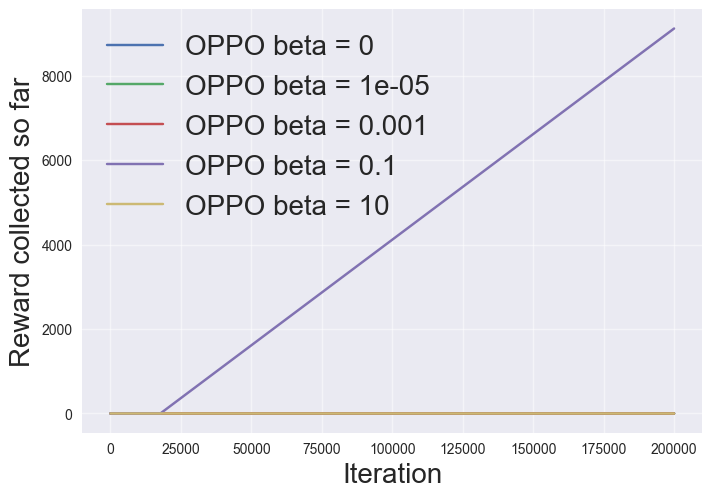

In [20]:
labels = [ f"OPPO beta = {beta}" for beta in betas]
plot_lines(
    to_plot,
    labels,
    ["Iteration", "Reward collected so far"],
    "figs",
    "ucbvseps",
    show=False
)

**Question**

Why does setting $\beta = 0$ lead to bad results? 

*Hint: Explain using the remarks in slide 28 and the theoretical bound in Slide 22 of Lecture 5*.

**Answer**

_Setting $\beta = 0$ in the function above removes the UCB bonus. The bonus promotes the exploration of less known pairs. As a result, the algorithm does not encourage exploration, therefore relying on the initial policy and tending to converge to the first policy that provides any reward, even if it is suboptimal._

**Question**

Why does setting $\beta$ too large lead to poor results?

*Hint: Answer using the regret bound for OPPO given at the beginning of slide 30.*

**Answer**

_If $\beta$ is too large, the bonus becomes also large. The regret bound for OPPO is defined as:_

$$ \sum_{t=1}^T V^\star(s_1) - V^{\pi_t}(s_1) \leq \mathcal{O}\left(\sum_{h=1}^H \sum_{t=1}^T \text{bonus}_h^t(s_h^t, a_h^t)\right) $$

_Therefore, if the bonus becomes large, the regret bound becomes very high. This results in favoring excessive exploration of suboptimal pairs, slowing down the convergence of the algorithm to the optimum._

# Ex 4: REINFORCE with parametrized policies (20 points)

In this exercise, we will investigate the effect of choosing different baselines in the reinforce implementation.
This topic is covered from Slide 31 on in Lecture 5.

**Hint: You may want to use Google Colab to run the experiments faster, but you don't have to.**

### Import the Necessary Packages

In [1]:
# TODO: you may need to run this to make sure to have the correct versions
!pip install gym==0.25.2
!pip install gym-notices==0.0.8

Defaulting to user installation because normal site-packages is not writeable


Defaulting to user installation because normal site-packages is not writeable


In [2]:
import gym
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 10)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(0)

import base64, io

# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Instantiate the Environment and Agent

The CartPole environment is very simple. It has discrete action space (2) and 4 dimensional state space.

In [4]:
env = gym.make('CartPole-v0')
env.seed(0)

C:\Users\rakib\AppData\Roaming\Python\Python311\site-packages\gym\envs\registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
C:\Users\rakib\AppData\Roaming\Python\Python311\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
C:\Users\rakib\AppData\Roaming\Python\Python311\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
C:\Users\rakib\AppData\Roaming\Python\Python311\site-packages\gym\core.py:256: DeprecationWarning: WARN: Function `env.seed(seed)` is mar

[0]

In [5]:
class Policy(nn.Module): # definie the policy network
    def __init__(self, state_size=4, action_size=2, hidden_size=32):
        super(Policy, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = self.fc2(x)
        return F.softmax(x, dim=1) # we just consider 1 dimensional probability of action

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        model = Categorical(probs)
        action = model.sample()
        return action.item(), model.log_prob(action)
    

In [6]:
# REINFORCE (with reward-to-go)
# --> with gradient estimator according to version 2 of the PG theorem (not using Q-values, but reward to go)
def reinforce_rwd2go(policy, optimizer, early_stop=False, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G = rewards_to_go[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

**Question**

1. Find **two** good baselines that improve over the implementation of REINFORCE without baseline. You should plot their results below.

You can take inspiration from the Example Notebook we attached for lecture 4, but you **cannot use exactly the same**.

2. Explain why you chose your baselines and why you think they are reasonable.

*Note:* You may also change other parameters such as the learning rate, as long as you clearly state it in your response.

**Answer**

The first baseline only focuses on the pole variables, mainly the pole angle and angular velocity. This is a natural choice because the main objective in CartPole is to keep the pole balanced. The terms involving $\theta^2$ and $\dot{\theta}^2$ can be seen as an energy-like measure: the pole is less stable when the angle is large or when it is rotating quickly. We also subtract a constant to roughly center the baseline values.

This baseline is reasonable because it is directly related to the physical state of the pole. States with small angle and small angular velocity are usually safer, while states with large angle or angular velocity are closer to failure. Therefore, this baseline should be correlated with the return-to-go and help reduce the variance of the REINFORCE update. However, the limitation of this baseline is that it ignores the cart motion completely. This means it may miss important information, for example when the cart is moving toward the boundary.

The second baseline extends the same idea by also including the cart position and velocity. It is still inspired by an energy-like interpretation, but now it takes into account both the pole dynamics and the cart dynamics. The pole terms represent instability due to the pole angle and angular velocity, while the cart terms represent how far the cart is from the center and whether it is moving toward the boundary.

This baseline is richer than the first one because it uses more of the state. It can distinguish situations where the pole looks similar but the cart is in a more dangerous position. This is why it is reasonable to expect it to reduce the variance more than the pole-only baseline. In our results, this second baseline gives better performance, which suggests that including the cart dynamics makes the baseline more correlated with the true return-to-go.


In [10]:
def naive_baseline(state): # Example Baseline from lecture 4 (for inspiration)
  angle = state[2]
  value = 100*(0.25-angle**2) # TO BE CHANGED USING YOUR BASELINE
  return value

def baseline_1(state): # TO BE CHANGED USING YOUR BASELINE 1
    pos, vel, angle, ang_vel = state
    return 50.0 * angle**2 + 35.0 * ang_vel**2 + 20.0 * angle * ang_vel - 10.0

def baseline_2(state): # TO BE CHANGED USING YOUR BASELINE 2
    pos, vel, angle, ang_vel = state
    pole_instability = 40.0 * angle**2 + 25.0 * ang_vel**2 + 15.0 * angle * ang_vel
    cart_instability = 8.0  * pos**2   + 5.0  * pos   * vel
    return pole_instability + cart_instability - 18.0

# PLOT 3: reward-to-go with baseline REINFORCE
# --> with gradient estimator according to version 3 of the PG theorem (not using Q-values, but reward to go)
# --> here, we consider only fixed (handcrafted) baseline functions b : S -> R; clearly, training a NN to predict V^{\pi}(s) as a baseline is also possible (and interesting!)
def reinforce_rwd2go_baseline(policy, optimizer, early_stop=False, baseline=naive_baseline, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        baseline_values = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            baseline_values.append(baseline(state))
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G_centered = rewards_to_go[i] - baseline_values[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G_centered)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

In [11]:
env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 1: run REINFORCE
policy_rwd2go = Policy().to(device)
optimizer_rwd2go = optim.Adam(policy_rwd2go.parameters(), lr=1e-2)
scores_rwd2go = reinforce_rwd2go(policy_rwd2go, optimizer_rwd2go, early_stop=False, n_episodes=2000)

env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 2: run REINFORCE and YOUR baseline 1
policy_baseline_1 = Policy().to(device)
optimizer_baseline_1 = optim.Adam(policy_baseline_1.parameters(), lr=1e-2)
scores_baseline_1 = reinforce_rwd2go_baseline(policy_baseline_1, optimizer_baseline_1, baseline=baseline_1, early_stop=False, n_episodes=2000)

env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 3: run REINFORCE and YOUR baseline 2
policy_baseline_2 = Policy().to(device)
optimizer_baseline_2 = optim.Adam(policy_baseline_2.parameters(), lr=1e-2)
scores_baseline_2 = reinforce_rwd2go_baseline(policy_baseline_2, optimizer_baseline_2, baseline=baseline_2, early_stop=False, n_episodes=2000)



Episode 100	Average Score: 50.79
Episode 200	Average Score: 89.22
Episode 300	Average Score: 137.68
Episode 400	Average Score: 149.37
Episode 500	Average Score: 138.12
Episode 600	Average Score: 150.80
Episode 700	Average Score: 166.40
Episode 800	Average Score: 113.40
Episode 900	Average Score: 130.71
Episode 1000	Average Score: 151.19
Episode 1100	Average Score: 177.52
Episode 1200	Average Score: 113.82
Episode 1300	Average Score: 169.80
Episode 1400	Average Score: 200.00
Episode 1500	Average Score: 200.00
Episode 1600	Average Score: 200.00
Episode 1700	Average Score: 200.00
Episode 1800	Average Score: 199.51
Episode 1900	Average Score: 200.00
Episode 100	Average Score: 101.98
Episode 200	Average Score: 171.48
Episode 300	Average Score: 175.05
Episode 400	Average Score: 160.38
Episode 500	Average Score: 186.20
Episode 600	Average Score: 200.00
Episode 700	Average Score: 198.10
Episode 800	Average Score: 190.34
Episode 900	Average Score: 137.69
Episode 1000	Average Score: 146.57
Episo

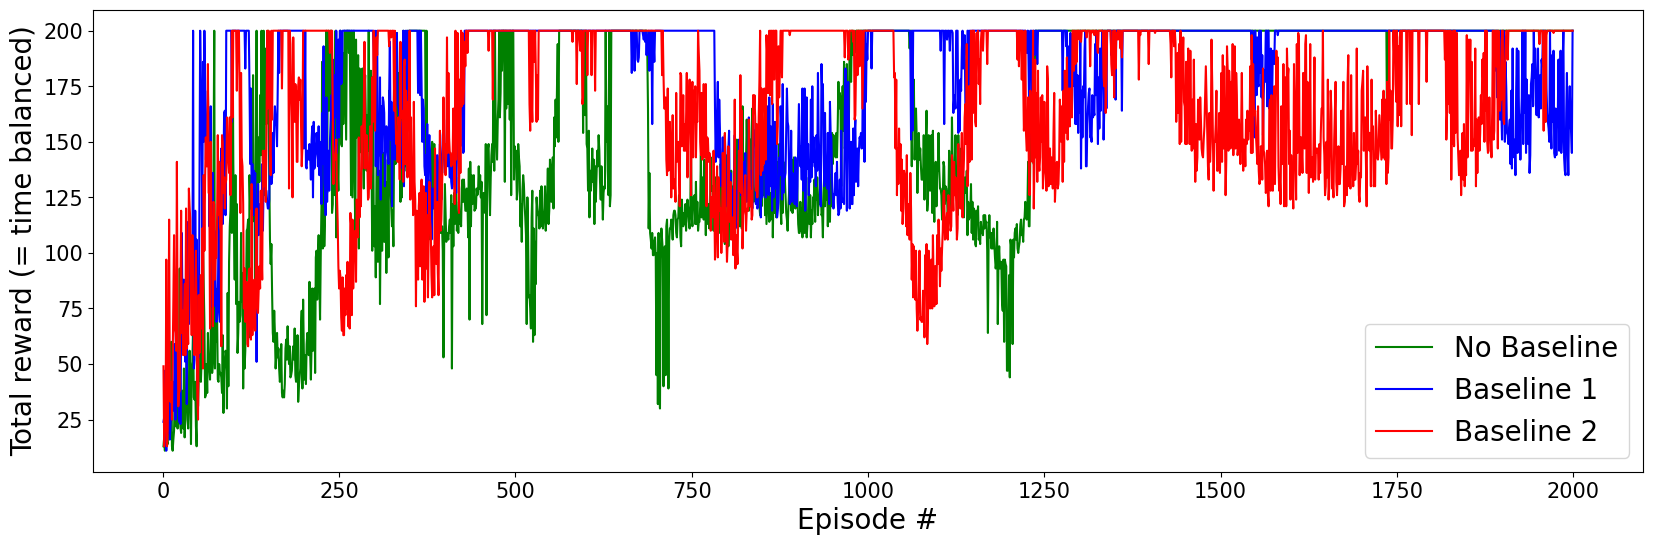

In [12]:
### Plot the learning progress

# Create the plot
fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(111)

# Plot the scores with specified colors and labels
ax.plot(np.arange(1, len(scores_rwd2go) + 1), scores_rwd2go, color='green', label='No Baseline')
ax.plot(np.arange(1, len(scores_baseline_1) + 1), scores_baseline_1, color='blue', label='Baseline 1')
ax.plot(np.arange(1, len(scores_baseline_2) + 1), scores_baseline_2, color='red', label='Baseline 2')

# Set the labels with a larger font size
ax.set_ylabel('Total reward (= time balanced)', fontsize=20)
ax.set_xlabel('Episode #', fontsize=20)

# Set the tick labels to a larger font size
ax.tick_params(axis='both', which='major', labelsize=15)

# Add a legend with a specified font size
ax.legend(fontsize=20)

# Show the plot
plt.show()

# $Q^\star$: Policy Gradient with continuous actions and bound on the bonuses count in OPPO (20 points)
***Question 1:*** Consider using a Gaussian parameterized policy $\pi_{\mu,\Sigma}$ with mean $\mu \in \mathrm{R}^d$ 
and covariance matrix $\Sigma$ . Write down the following gradients:

$$ \nabla_\mu J(\pi_{\mu, \Sigma}) = \dfrac{1}{1-\gamma} \mathbb{E}[A^{\pi_{\mu, \Sigma}}(s,a) \nabla_\mu\log \pi_{\mu, \Sigma}(a | s)]$$
$$ \nabla_\Sigma J(\pi_{\mu, \Sigma}) =  \dfrac{1}{1-\gamma} \mathbb{E}[A^{\pi_{\mu, \Sigma}}(s, a) \nabla_\Sigma\log \pi_{\mu, \Sigma}(a | s)]$$
***Question 2*** In this exercise, you will bound the state action counts. This is a crucial part of the OPPO convergence proof. Let $N^t_h(s,a)$ denotes the number of times the state action pair $s,a$ has been visited at step $h$ in all the episode up to $t$ included. Moreover,
let $s^t_h,a^t_h$ be the state action pair visited at step $h$ of the $t^{th}$ episode. Then, prove that 
$$ \sum^T_{t=1} \sum^H_{h=1} \frac{1}{N^t_h(s^t_h, a^t_h)+1} \leq SAH \log( T H)$$
***Question 3*** Use the fact above to prove the following bound at slide 30 of Lecture 5. That is, for $\mathrm{bonus}^t_h(s,a) = \frac{H}{\sqrt{N^t_h(s,a)+1}}$ it holds that
$$ \sum^T_{t=1} \sum^H_{h=1} \mathrm{bonus}(s^t_h, a^t_h) \leq \sqrt{ H^3 SA T \log( T H)}$$

**Answer 1**

We use the policy gradient theorem in the form:

$$
\nabla_\theta J(\pi_\theta)
=
\frac{1}{1-\gamma}
\mathbb{E}_{(s,a)\sim \lambda^\pi}
\left[
A^\pi(s,a)\nabla_\theta \log \pi_\theta(a|s)
\right].
$$

Here the policy is Gaussian with parameters $\mu$ and $\Sigma$:

$$
\pi_{\mu,\Sigma}(a|s)
=
\frac{1}{\sqrt{(2\pi)^d|\Sigma|}}
\exp\left(
-\frac{1}{2}(a-\mu)^T\Sigma^{-1}(a-\mu)
\right).
$$

Taking the log gives:

$$
\log \pi_{\mu,\Sigma}(a|s)
=
-\frac{d}{2}\log(2\pi)
-\frac{1}{2}\log|\Sigma|
-\frac{1}{2}(a-\mu)^T\Sigma^{-1}(a-\mu).
$$

For the gradient with respect to the mean, only the last term depends on $\mu$. Therefore:

$$
\nabla_\mu \log \pi_{\mu,\Sigma}(a|s)
=
\Sigma^{-1}(a-\mu).
$$

So we get:

$$
\nabla_\mu J(\pi_{\mu,\Sigma})
=
\frac{1}{1-\gamma}
\mathbb{E}
\left[
A^\pi(s,a)\Sigma^{-1}(a-\mu)
\right].
$$

For the covariance matrix, we differentiate the two terms that depend on $\Sigma$:

$$
-\frac{1}{2}\log|\Sigma|
\quad \text{and} \quad
-\frac{1}{2}(a-\mu)^T\Sigma^{-1}(a-\mu).
$$

Using the usual matrix derivatives, we obtain:

$$
\nabla_\Sigma \log \pi_{\mu,\Sigma}(a|s)
=
\frac{1}{2}
\Sigma^{-1}
\left[
(a-\mu)(a-\mu)^T - \Sigma
\right]
\Sigma^{-1}.
$$

Therefore:

$$
\nabla_\Sigma J(\pi_{\mu,\Sigma})
=
\frac{1}{2(1-\gamma)}
\mathbb{E}
\left[
A^\pi(s,a)
\Sigma^{-1}
\left[
(a-\mu)(a-\mu)^T - \Sigma
\right]
\Sigma^{-1}
\right].
$$

This gives the gradients for both parameters of the Gaussian policy.

---

**Answer 2**

We want to bound the sum:

$$
\sum_{t=1}^{T}\sum_{h=1}^{H}
\frac{1}{N_h^t(s_h^t,a_h^t)+1}.
$$

The idea is to group the terms by state-action pair and timestep. So we fix one triple $(s,a,h)$ and look only at the times where this specific pair $(s,a)$ is visited at timestep $h$.

Suppose this happens $K_{s,a,h}$ times during the $T$ episodes. At the first visit, the counter is equal to $1$, at the second visit it is equal to $2$, and so on. Therefore, the contribution of this fixed triple is bounded by:

$$
\sum_{i=1}^{K_{s,a,h}} \frac{1}{i+1}.
$$

This is a harmonic sum, so we can bound it by a logarithm:

$$
\sum_{i=1}^{K_{s,a,h}} \frac{1}{i+1}
\leq
\sum_{i=1}^{K_{s,a,h}} \frac{1}{i}
\leq
1 + \log(K_{s,a,h}).
$$

Since a fixed triple $(s,a,h)$ can be visited at most once per episode, we have:

$$
K_{s,a,h} \leq T.
$$

So:

$$
1 + \log(K_{s,a,h})
\leq
1 + \log(T).
$$

Up to constants, this is bounded by $\log(TH)$. Finally, there are at most $S$ states, $A$ actions, and $H$ timesteps, so there are at most $SAH$ triples. Hence:

$$
\sum_{t=1}^{T}\sum_{h=1}^{H}
\frac{1}{N_h^t(s_h^t,a_h^t)+1}
\leq
SAH\log(TH).
$$

So the total sum grows only logarithmically with the number of episodes for each state-action-timestep triple.

---

**Answer 3**

We now want to bound the total exploration bonus. The bonus has the form:

$$
\text{bonus}_h^t(s,a)
=
\frac{H}{\sqrt{N_h^t(s,a)+1}}.
$$

Therefore:

$$
\sum_{t=1}^{T}\sum_{h=1}^{H}
\text{bonus}_h^t(s_h^t,a_h^t)
=
H
\sum_{t=1}^{T}\sum_{h=1}^{H}
\frac{1}{\sqrt{N_h^t(s_h^t,a_h^t)+1}}.
$$

We apply Cauchy-Schwarz to the second sum:

$$
\sum_{t,h}
\frac{1}{\sqrt{N_h^t(s_h^t,a_h^t)+1}}
\leq
\sqrt{TH}
\sqrt{
\sum_{t,h}
\frac{1}{N_h^t(s_h^t,a_h^t)+1}
}.
$$

From Answer 2, we already know that:

$$
\sum_{t,h}
\frac{1}{N_h^t(s_h^t,a_h^t)+1}
\leq
SAH\log(TH).
$$

Plugging this into the previous inequality gives:

$$
\sum_{t,h}
\frac{1}{\sqrt{N_h^t(s_h^t,a_h^t)+1}}
\leq
\sqrt{TH}
\sqrt{SAH\log(TH)}.
$$

So:

$$
\sum_{t,h}
\frac{1}{\sqrt{N_h^t(s_h^t,a_h^t)+1}}
\leq
H\sqrt{SAT\log(TH)}.
$$

Finally, we multiply by the extra factor $H$ from the bonus definition:

$$
\sum_{t=1}^{T}\sum_{h=1}^{H}
\text{bonus}_h^t(s_h^t,a_h^t)
\leq
H^2\sqrt{SAT\log(TH)}.
$$

Equivalently, this can be written as:

$$
\sum_{t=1}^{T}\sum_{h=1}^{H}
\text{bonus}_h^t(s_h^t,a_h^t)
\leq
\sqrt{H^4SAT\log(TH)}.
$$

This proves the required bound.